Models:
- Logistic Regression
- Tree Decision
- Random Forest
- CatBoost
- XGBoost
- Light GBM

For imbalance fix:
- `class-weight`
- `undersampling` & `oversampling`
- `SMOTE`

In [ ]:
import pandas as pd
import numpy as np
import time

from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.model_selection import GridSearchCV
import optuna

from sklearn.metrics import (precision_score,
                             recall_score,
                             average_precision_score,
                             f1_score)

import joblib

In [ ]:
RANDOM_SEED = 42
df = pd.read_csv('../data/Synthetic_Financial_datasets_log.csv')

## New Features

In [ ]:
df['log_amount'] = np.log1p(df['amount'])
df['day'] = (df['step'] - 1) // 24
df['hour'] = (df['step'] - 1) % 24
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

features = ['step', 'type',
            'amount', 'log_amount',
            'day', 'hour_sin',
            'hour_cos']

target = ['isFraud']

df = df[features + target]

df['type'] = df['type'].astype('category')

In [ ]:
test_point = 550
calibration_point = test_point - 50
validation_point = calibration_point - 100

test = df[df['step'] > test_point].copy()
calibration = df[(df['step'] <= test_point) & (df['step'] > calibration_point)].copy()
validation = df[(df['step'] <= calibration_point) & (df['step'] > validation_point)].copy()
train = df[df['step'] <= validation_point].copy()

In [ ]:
X_train, y_train = train.drop('isFraud', axis=1), train['isFraud']
X_val, y_val = validation.drop('isFraud', axis=1), validation['isFraud']
X_cal, y_cal = calibration.drop('isFraud', axis=1), calibration['isFraud']
X_test, y_test = test.drop('isFraud', axis=1), test['isFraud']

In [ ]:
categorial_features = ['type']
numeric_features = ['amount', 'log_amount']
other_features =['step', 'day', 'hour_sin', 'hour_cos']

## Pipelines

### Logistic Regression

#### Logistic Regression Preprocessing

In [ ]:
log_reg_preprocessor = ColumnTransformer(transformers=[
    ('numeric', StandardScaler(), numeric_features),
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features)
])

#### Logistic Regression Pipelines

In [ ]:
log_reg_models = {
    'base': Pipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_SEED)
        )
    ]),

    'balanced': Pipeline(steps=[
        ('preprocessor', log_reg_preprocessor),
        ('classifier', LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=RANDOM_SEED)
        )
    ])
}

### Decision Tree Classifier

#### Decision Tree Preprocessor

In [ ]:
dt_preprocessor = ColumnTransformer(transformers=[
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features + numeric_features)
])

#### Decision Tree Pipelines

In [ ]:
df_models = {

    # base
    'base': Pipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('classifier', DecisionTreeClassifier(
            class_weight=None,
            max_depth=20,
            random_state=RANDOM_SEED
        ))
    ]),

    # balanced
    'balanced': Pipeline(steps=[
        ('preprocessor', dt_preprocessor),
        ('classifier', DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=20,
            random_state=RANDOM_SEED
        ))
    ])
}

### Random Forest

#### Random Forest Preprocessor

In [ ]:
rf_preprocessor = ColumnTransformer(transformers=[
    ('categorical', OneHotEncoder(), categorial_features),
    ('others', 'passthrough', other_features + numeric_features)
])

#### Random Forest Pipelines

In [ ]:
rf_models = {

    # base
    'base': Pipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight=None,
            max_depth=20,
            n_jobs=-1,
            n_estimators=10,
            random_state=RANDOM_SEED
        ))
    ]),

    # balanced
    'balanced': Pipeline(steps=[
        ('preprocessor', rf_preprocessor),
        ('classifier', RandomForestClassifier(
            class_weight='balanced',
            max_depth=20,
            n_jobs=-1,
            n_estimators=10,
            random_state=RANDOM_SEED
        ))
    ])
}

### XGBoost

#### XGBoost Pipelines

In [ ]:
xgb_models = {

    'base': XGBClassifier(
        enable_categorical=True,
        n_jobs=-1,
        random_state=RANDOM_SEED
    )
}

### Catboost

#### Catboost Pipelines

In [ ]:
cb_models = {
    'base': CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',

        thread_count=4,
        used_ram_limit='6gb',

        random_seed=RANDOM_SEED,
        verbose=False
    ),

    'balanced': CatBoostClassifier(
        iterations=300,
        depth=6,
        learning_rate=0.1,
        loss_function='Logloss',

        auto_class_weights='Balanced',

        thread_count=4,
        used_ram_limit='6gb',

        random_seed=RANDOM_SEED,
        verbose=False
    )
}

catboost_fit_params={
    'cat_features': ['type'],
    'eval_set': (X_val, y_val),
    'early_stopping_rounds': 50,
    'verbose': False
}

### Light Gradient Boosting

#### LGBM Pipelines

In [ ]:
lgbm_models = {

    # base
    'base': LGBMClassifier(
        objective='binary',
        class_weight=None,
        n_estimators=300,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=8,
        min_child_samples=50,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        n_jobs=-1,
        verbosity=-1,
        random_state=RANDOM_SEED
    ),

    # balanced
    'balanced': LGBMClassifier(
        class_weight='balanced',
        objective='binary',
        n_estimators=300,
        learning_rate=0.1,
        num_leaves=31,
        max_depth=8,
        min_child_samples=50,
        subsample=0.8,
        subsample_freq=1,
        colsample_bytree=0.8,
        n_jobs=-1,
        verbosity=-1,
        random_state=RANDOM_SEED
    )
}

lgbm_fit_params={
    'categorical_feature': ['type'],
    'eval_X': X_val,
    'eval_y': y_val,
    'eval_metric': 'average_precision',
    'callbacks': [
        lgb.early_stopping(50),
        lgb.log_evaluation(0)
    ]
}

### Results

In [ ]:
sampling_strategies = {
    'base': None,

    'under.05': RandomUnderSampler(
        sampling_strategy=0.05,
        random_state=RANDOM_SEED
    ),

    'under.10': RandomUnderSampler(
        sampling_strategy=0.10,
        random_state=RANDOM_SEED
    ),

    'under.20': RandomUnderSampler(
        sampling_strategy=0.20,
        random_state=RANDOM_SEED
    ),

    'over.005': RandomOverSampler(
        sampling_strategy=0.005,
        random_state=RANDOM_SEED
    ),

    'over.01': RandomOverSampler(
        sampling_strategy=0.01,
        random_state=RANDOM_SEED
    ),

    'over.02': RandomOverSampler(
        sampling_strategy=0.02,
        random_state=RANDOM_SEED
    ),

    'smote.01': SMOTENC(
        categorical_features=['type'],
        sampling_strategy=0.01,
        random_state=RANDOM_SEED,
        k_neighbors=5
    ),

    'smote.02': SMOTENC(
        categorical_features=['type'],
        sampling_strategy=0.02,
        random_state=RANDOM_SEED,
        k_neighbors=5
    ),
}

In [ ]:
models_dict = {
    'Logistic Regression': log_reg_models,
    'Decision Tree': df_models,
    'Random Forest': rf_models,
    'XGBoost': xgb_models,
    'Catboost': cb_models,
    'LGBM': lgbm_models
}

In [ ]:
def apply_sampling(X, y, sampler):
    if sampler is None:
        return X.copy(), y.copy()

    X_resampled, y_resampled = sampler.fit_resample(X, y)

    X_resampled['type'] = X_resampled['type'].astype('category')

    return X_resampled, y_resampled

In [ ]:
def model_estimation(y_true, y_proba, threshold=0.5):
    y_pred = (y_proba >= threshold).astype(int)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    average_precision = average_precision_score(y_true, y_proba)

    return {
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'average_precision': average_precision,
    }

In [ ]:
def evaluate_model(
        model_name,
        model,
        X_train,
        y_train,
        X_val,
        y_val,
        sampler_name=None,
        sampler=None,
        fit_params=None
):
    X_sampled, y_sampled = apply_sampling(
        X_train,
        y_train,
        sampler
    )

    start = time.time()

    if fit_params is None:
        fit_params = {}

    model.fit(
        X_sampled,
        y_sampled,
        **fit_params
    )

    training_time = time.time() - start

    y_proba = model.predict_proba(X_val)[:, 1]

    metrics = model_estimation(
        y_val,
        y_proba
    )

    metrics['model'] = model_name
    metrics['sampling'] = sampler_name
    metrics['fit_time'] = round(training_time, 0)

    return model, metrics

In [ ]:
# res_val_table = pd.DataFrame(
#     columns=[
#         'model',
#         'sampling',
#         'precision',
#         'recall',
#         'f1',
#         'average_precision',
#         'fit_time'
#     ]
# )

**Code bellow commented because it works about hour**

In [ ]:
# for name, model in models_dict.items():
#     print(name)
#
#     if name == 'Catboost':
#         fit_params = catboost_fit_params
#     elif name == 'LGBM':
#         fit_params = lgbm_fit_params
#     else:
#         fit_params = None
#
#     for name_conf, model_conf in model.items():
#
#         if name_conf == 'balanced':
#             print('\t balanced')
#             fitted_model, metrics = evaluate_model(
#                 model_name=name,
#                 model=model_conf,
#                 X_train=X_train,
#                 y_train=y_train,
#                 X_val=X_val,
#                 y_val=y_val,
#                 sampler_name='balanced',
#                 sampler=None,
#                 fit_params=fit_params
#             )
#             res_val_table = pd.concat([res_val_table, pd.DataFrame([metrics])], ignore_index=True)
#
#         else:
#             for sampling_name, sampling_strategy in sampling_strategies.items():
#                 print(f'\t {sampling_name}')
#                 fitted_model, metrics = evaluate_model(
#                     model_name=name,
#                     model=model_conf,
#                     X_train=X_train,
#                     y_train=y_train,
#                     X_val=X_val,
#                     y_val=y_val,
#                     sampler_name=sampling_name,
#                     sampler=sampling_strategy,
#                     fit_params=fit_params
#                 )
#                 res_val_table = pd.concat([res_val_table, pd.DataFrame([metrics])], ignore_index=True)
#     print()
#
# res_val_table.sort_values(by='average_precision', ascending=False).head(15)

CatBoost provided strong ranking performance, but LightGBM achieved higher Average Precision while training substantially faster.

![image.png](attachment:782a0723-787e-4863-9e42-6ef5650803e8.png)

### Models selected for hyperparameter tuning

Based on validation Average Precision from the initial model comparison,
LightGBM and CatBoost were selected for further hyperparameter tuning.

XGBoost was not included in the tuning stage because its baseline
performance was lower than the two leading boosting models, while
requiring additional computational resources

## Hyperparameter Tuning

### Catboost tuning

In [ ]:
# def objective_catboost(trial):
#
#     params = {
#         'iterations': trial.suggest_int('iterations', 100, 1000),
#
#         'depth': trial.suggest_int('depth', 4, 8),
#
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15,log=True),
#
#         'l2_leaf_reg': trial.suggest_float(
#             'l2_leaf_reg', 1, 20, log=True),
#
#         'random_strength': trial.suggest_float(
#             'random_strength', 0.01, 5, log=True),
#
#         'bagging_temperature': trial.suggest_float(
#             'bagging_temperature', 0, 2),
#
#         'auto_class_weights': 'Balanced',
#
#         'loss_function': 'Logloss',
#
#         # 'thread_count': 4,
#         # 'used_ram_limit': '6gb',
#
#         'random_seed': RANDOM_SEED,
#         'verbose': False
#     }
#
#
#     model = CatBoostClassifier(**params)
#
#     model.fit(
#         X_train,
#         y_train,
#
#         cat_features=['type'],
#
#         eval_set=(X_val, y_val),
#
#         early_stopping_rounds=50,
#
#         verbose=False
#     )
#
#     y_proba = model.predict_proba(X_val)[:, 1]
#
#     return average_precision_score(
#         y_val,
#         y_proba
#     )
#
# study_catboost = optuna.create_study(
#     direction='maximize',
# )
#
#
# study_catboost.optimize(
#     objective_catboost,
#     n_trials=20
# )

In [ ]:
# catboost_model = CatBoostClassifier(**study_catboost.best_params)

# catboost_model.set_params(
#     random_state=RANDOM_SEED,
#     verbose=False,
#     auto_class_weights='Balanced',
# )
#
# catboost_model, catboost_metrics = evaluate_model(
#     model_name='Best catboost',
#     model=catboost_model,
#     X_train=X_train,
#     y_train=y_train,
#     X_val=X_val,
#     y_val=y_val,
#     fit_params=catboost_fit_params
# )

# joblib.dump(catboost_model, "../models/catboost_model.joblib")

### LightGBM tuning

In [ ]:
# def objective_lgbm(trial):
#
#     params = {
#         'objective': 'binary',
#         'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
#
#         'learning_rate': trial.suggest_float(
#             'learning_rate', 0.01, 0.15, log=True),
#
#         'num_leaves': trial.suggest_int('num_leaves', 15, 127),
#         'max_depth': trial.suggest_int('max_depth', 4, 12),
#
#         'min_child_samples': trial.suggest_int(
#             'min_child_samples', 20, 200),
#
#         'subsample': trial.suggest_float(
#             'subsample', 0.6, 1.0),
#
#         'subsample_freq': 1,
#
#         'reg_alpha': trial.suggest_float(
#             'reg_alpha', 1e-8, 10.0, log=True),
#
#         'reg_lambda': trial.suggest_float(
#             'reg_lambda', 1e-8, 10.0, log=True),
#
#         'class_weight': 'balanced',
#
#         'n_jobs': 4,
#         'random_state': RANDOM_SEED,
#         'verbosity': -1
#     }
#
#     model = LGBMClassifier(**params)
#
#     model.fit(
#         X_train,
#         y_train,
#         categorical_feature=['type'],
#         eval_X=X_val,
#         eval_y=y_val,
#         eval_metric='average_precision',
#         callbacks=[
#             lgb.early_stopping(50, verbose=False)
#         ]
#     )
#
#     y_proba = model.predict_proba(X_val)[:, 1]
#
#     return average_precision_score(
#         y_val,
#         y_proba
#     )
#
#
# study_lgbm = optuna.create_study(
#     direction='maximize'
# )
#
# study_lgbm.optimize(
#     objective_lgbm,
#     n_trials=30
# )

In [ ]:
# lgbm_model = LGBMClassifier(**study_lgbm.best_params)

# lgbm_model.set_params(
#     n_jobs=-1,
#     verbosity=-1,
#     random_state=RANDOM_SEED,
#     class_weight='balanced',
#     objective='binary'
# )
#
# lgbm_model, lgbm_metrics = evaluate_model(
#     model_name='Best lgbm',
#     model=lgbm_model,
#     X_train=X_train,
#     y_train=y_train,
#     X_val=X_val,
#     y_val=y_val,
#     fit_params=lgbm_fit_params
# )

# joblib.dump(lgbm_model, "../models/lgbm_model.joblib")

### Best models estimation

In [79]:
# optimized_results = (pd.concat(
#     [
#         pd.DataFrame([catboost_metrics]),
#         pd.DataFrame([lgbm_metrics]),
#     ]
# ).set_index('model')
#                      .drop('sampling', axis=1).
#                      sort_values(by='average_precision',
#                      ascending=False))
#
# optimized_results

,precision,recall,f1,average_precision,fit_time
model,,,,,
Best catboost,0.028554,0.870849,0.055295,0.370379,237.0
Best lgbm,0.028396,0.866236,0.054989,0.361779,23.0
Best xgb,0.245057,0.377306,0.297130,0.268497,258.0


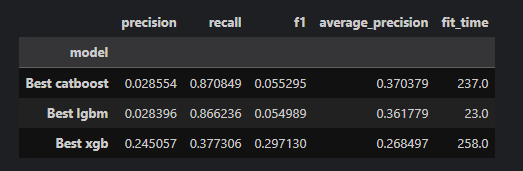

**Best models loading (for time saving)**

In [80]:
catboost_model = joblib.load(r'..\models\catboost_model.joblib')
lgbm_model = joblib.load(r'..\models\lgbm_model.joblib')

## Calibration